# EXXA Test Submission — End-to-End Pipeline

This notebook runs the full PLANAR pipeline from start to finish (General + Image + Sequential tests), produces all required plots/metrics, and demonstrates withheld-data inference.


In [1]:
# Ensure local package imports work
import os
import sys
from pathlib import Path
root = Path.cwd()
while root != root.parent and not (root / "src" / "planar").exists():
    root = root.parent
os.chdir(root)
src = root / "src"
for entry in ("", str(root)):
    while entry in sys.path:
        sys.path.remove(entry)
if str(src) not in sys.path:
    sys.path.insert(0, str(src))
print("Using repo root:", root)


Using repo root: /Users/atharva/Desktop/untitled folder/PLANAR


In [2]:
# Clone repo and install dependencies (Colab-friendly)
import os
from pathlib import Path
in_colab = "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ
repo_root = Path.cwd()
if not (repo_root / "src" / "planar").exists():
    !git clone https://github.com/Atharva12081/PLANAR.git
    %cd PLANAR
    repo_root = Path.cwd()
if in_colab:
    !pip install -r requirements.txt
    !pip install -e .


In [3]:
# Verify MS-SSIM dependency is available
from planar.metrics import HAS_MS_SSIM
print('MS-SSIM available:', HAS_MS_SSIM)


MS-SSIM available: True


## Run Full Pipeline
This runs: autoencoder training → clustering → transit classifier → inference → report.


In [4]:
!python -m planar run --config configs/verify.yaml


2026-03-13 15:45:23,413 | INFO | planar.pipelines.autoencoder | AE loaded pretrained checkpoint; val_loss=0.03757 val_mse=0.00806


2026-03-13 15:45:25,293 | INFO | planar.pipelines.autoencoder | Autoencoder artifacts written to artifacts/autoencoder


/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify

/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeW

2026-03-13 15:45:29,375 | INFO | planar.pipelines.clustering | Clustering complete: method=hdbscan_all_noise_fallback_kmeans reducer=pca silhouette=0.33633577823638916 noise=0.000


2026-03-13 15:45:34,416 | INFO | planar.pipelines.transit | Transit training complete. test_auc=0.9962 stress_auc=0.9612


/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: Runtime

2026-03-13 15:45:41,204 | INFO | planar.pipelines.inference | Inference complete, outputs written to artifacts/inference


2026-03-13 15:45:41,242 | INFO | planar.pipelines.full | Run report written to reports/PLANAR_REPORT.md


## Inspect Outputs & Metrics


In [5]:
from pathlib import Path
import json
art = Path("artifacts")
print("Autoencoder summary:")
print(json.loads((art/"autoencoder"/"train_summary.json").read_text()))
print("\nClustering summary:")
print(json.loads((art/"clustering"/"clustering_summary.json").read_text()))
print("\nTransit summary:")
print(json.loads((art/"transit"/"train_summary.json").read_text()))


Autoencoder summary:
{'best_val_loss': 0.037572833709418774, 'ms_ssim_available': True, 'num_files_loaded': 150, 'num_files_skipped': 0, 'skipped_examples': [], 'split_integrity': {'coverage_fraction': 1.0, 'covered_samples': 150, 'leakage_detected': False, 'n_samples': 150, 'overlap_train_val': 0}, 'train_size': 120, 'used_pretrained': True, 'val_size': 30}

Clustering summary:
{'bias_summary': {'axis_ratio_eta_squared': 0.648009699999844, 'axis_ratio_kruskal_p': 6.78092741478593e-21, 'brightness_eta_squared': 0.6920774915379251, 'brightness_kruskal_p': 1.3612187905325606e-20, 'dominance_flags': {'brightness_dominated': True, 'orientation_dominated': True}}, 'debias_diagnostics': None, 'debias_nuisance_latent': False, 'method_requested': 'hdbscan', 'method_used': 'hdbscan_all_noise_fallback_kmeans', 'metrics': {'noise_fraction': 0.0, 'num_clusters': 6, 'silhouette': 0.33633577823638916}, 'negative_controls': {'permuted_latent_refit': {'method_used': 'hdbscan_all_noise_fallback_kmeans'

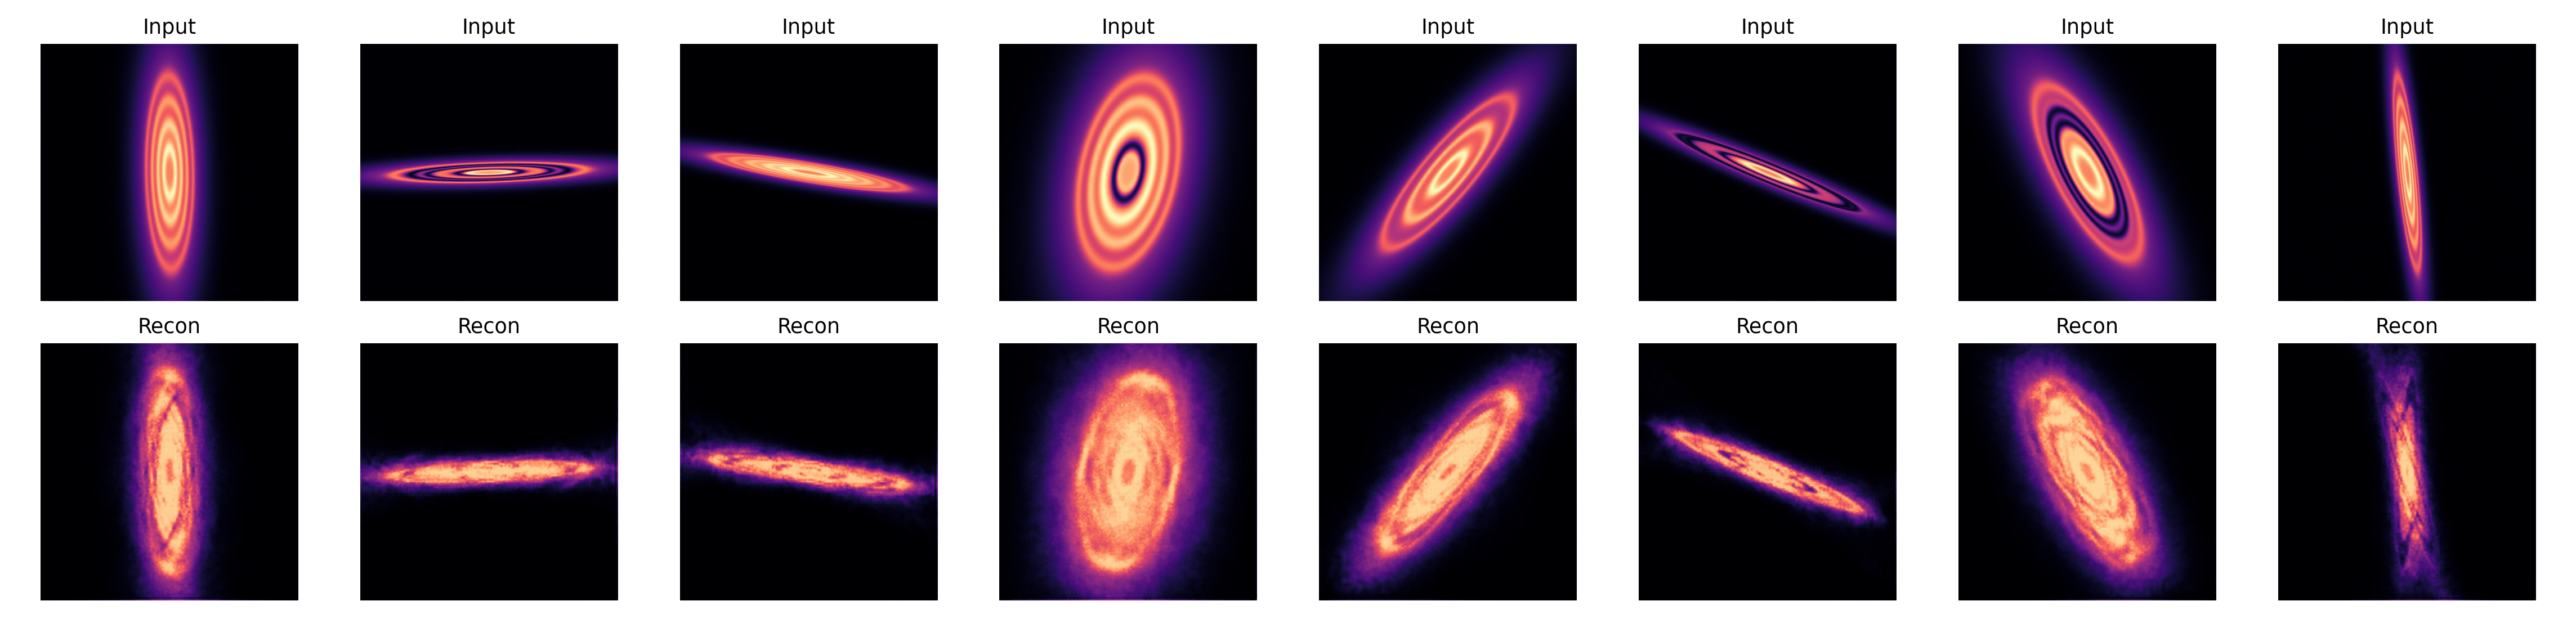

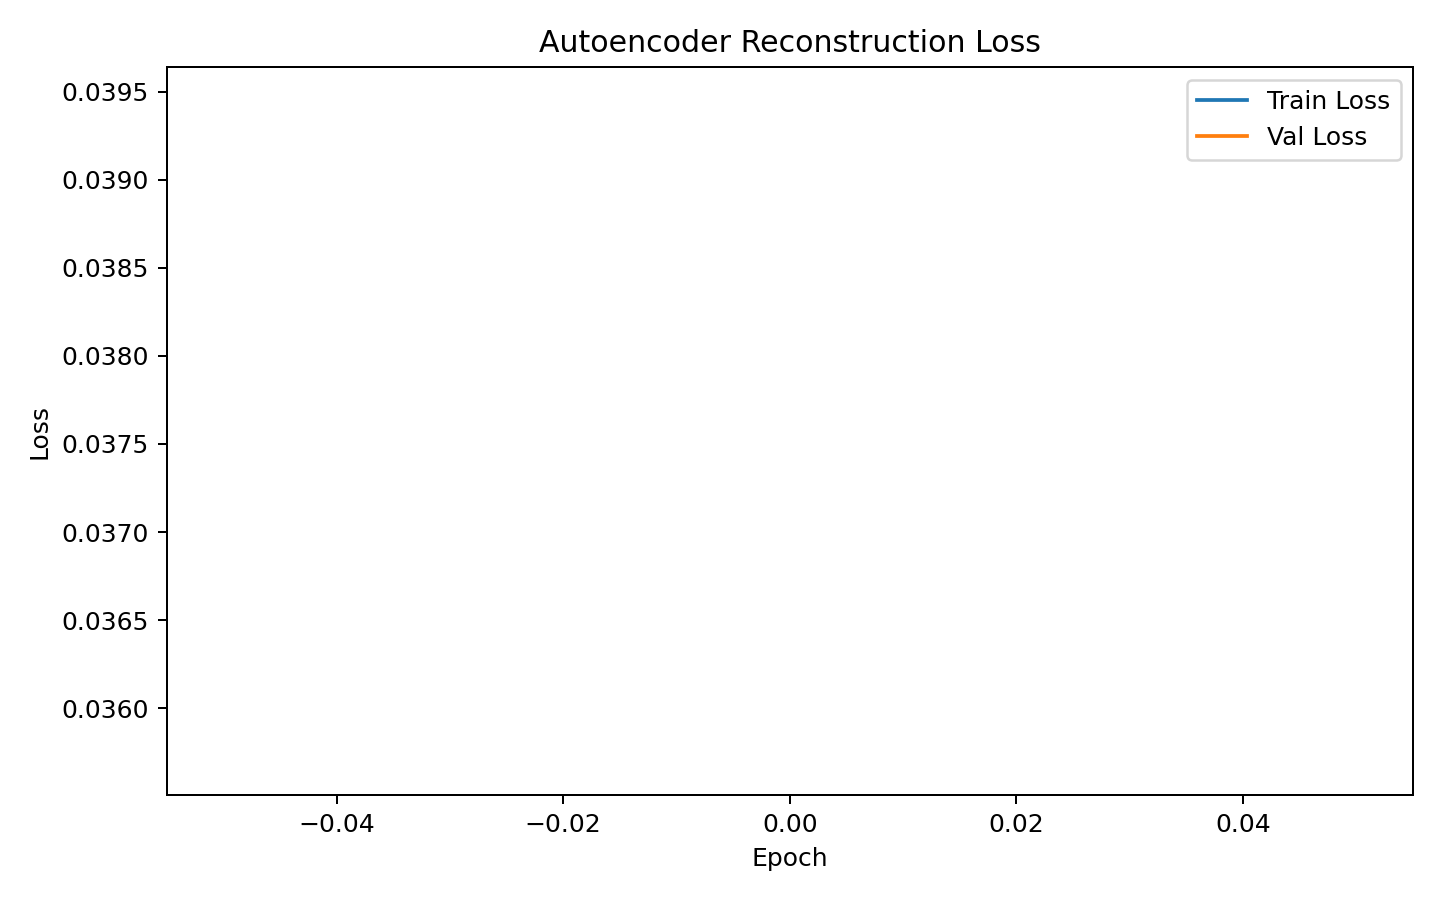

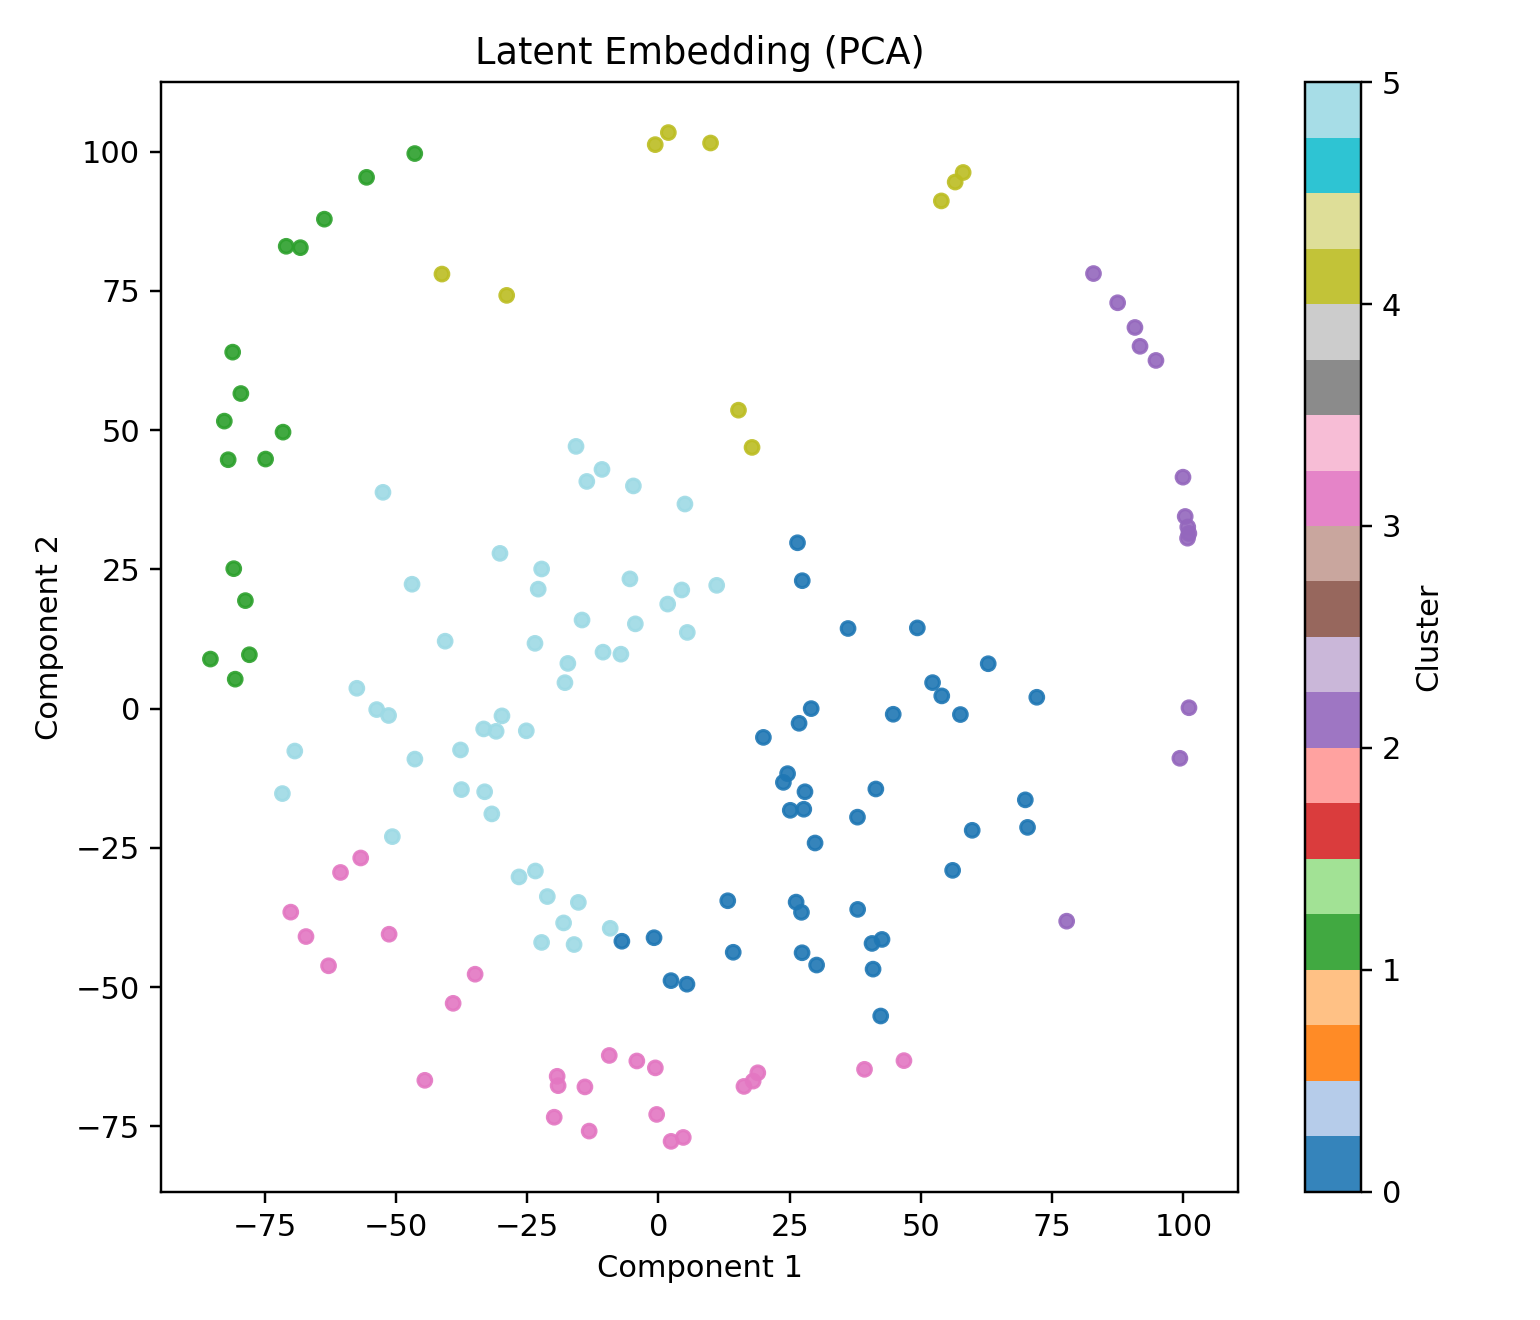

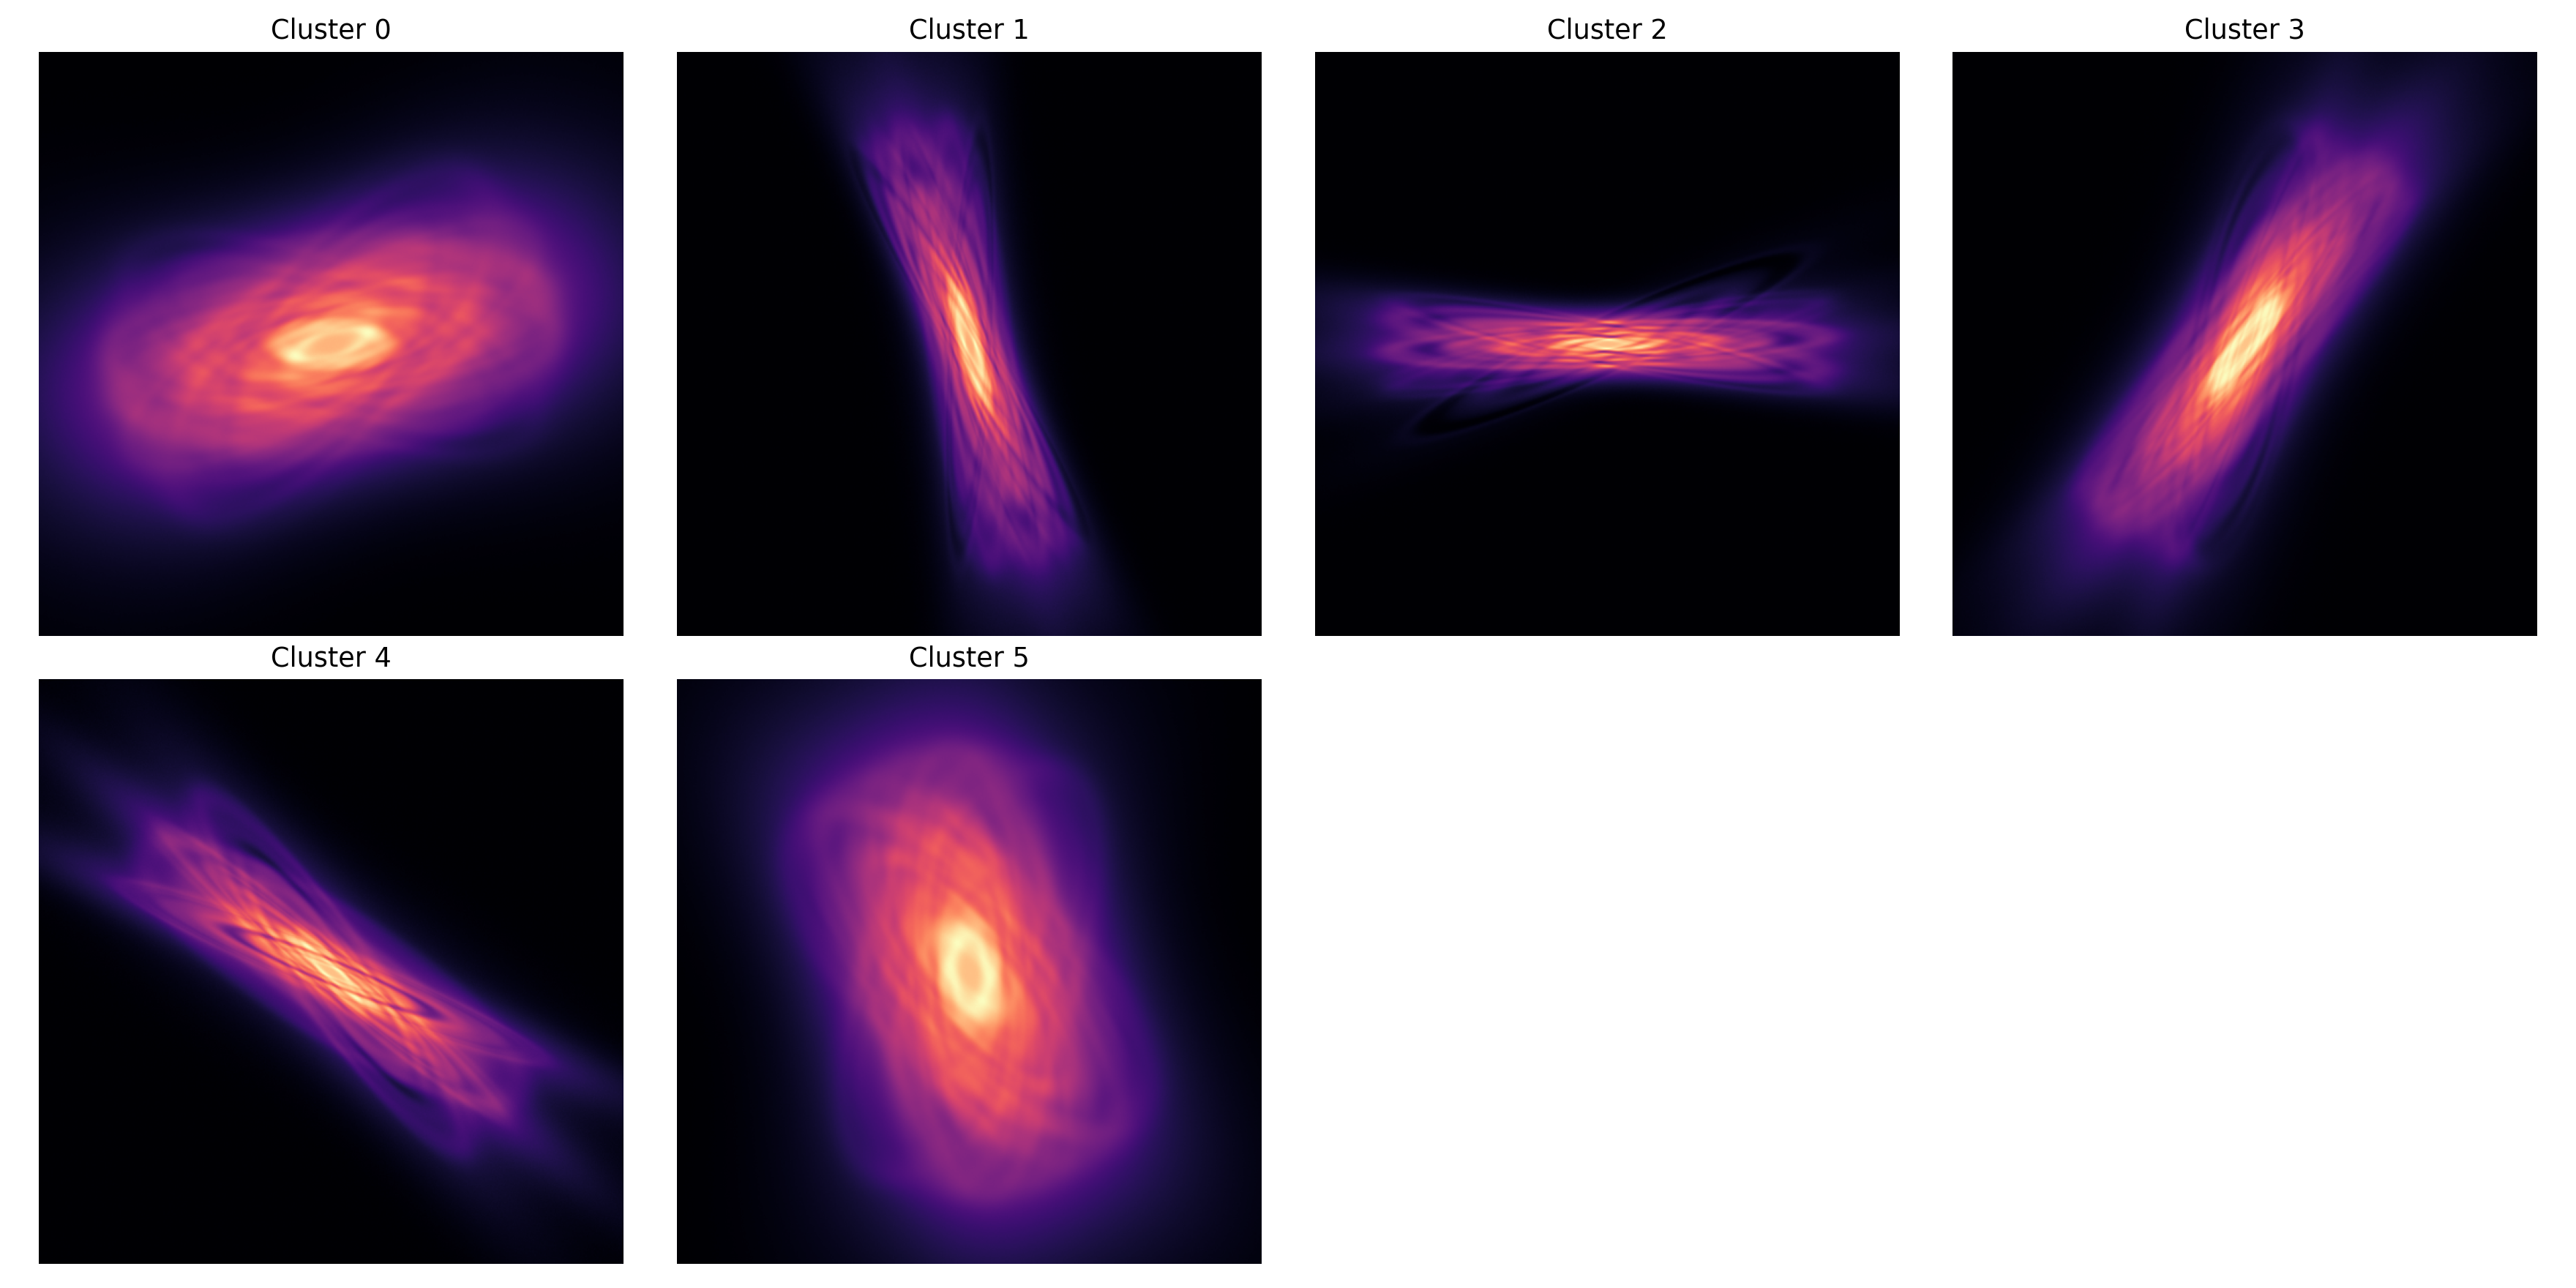

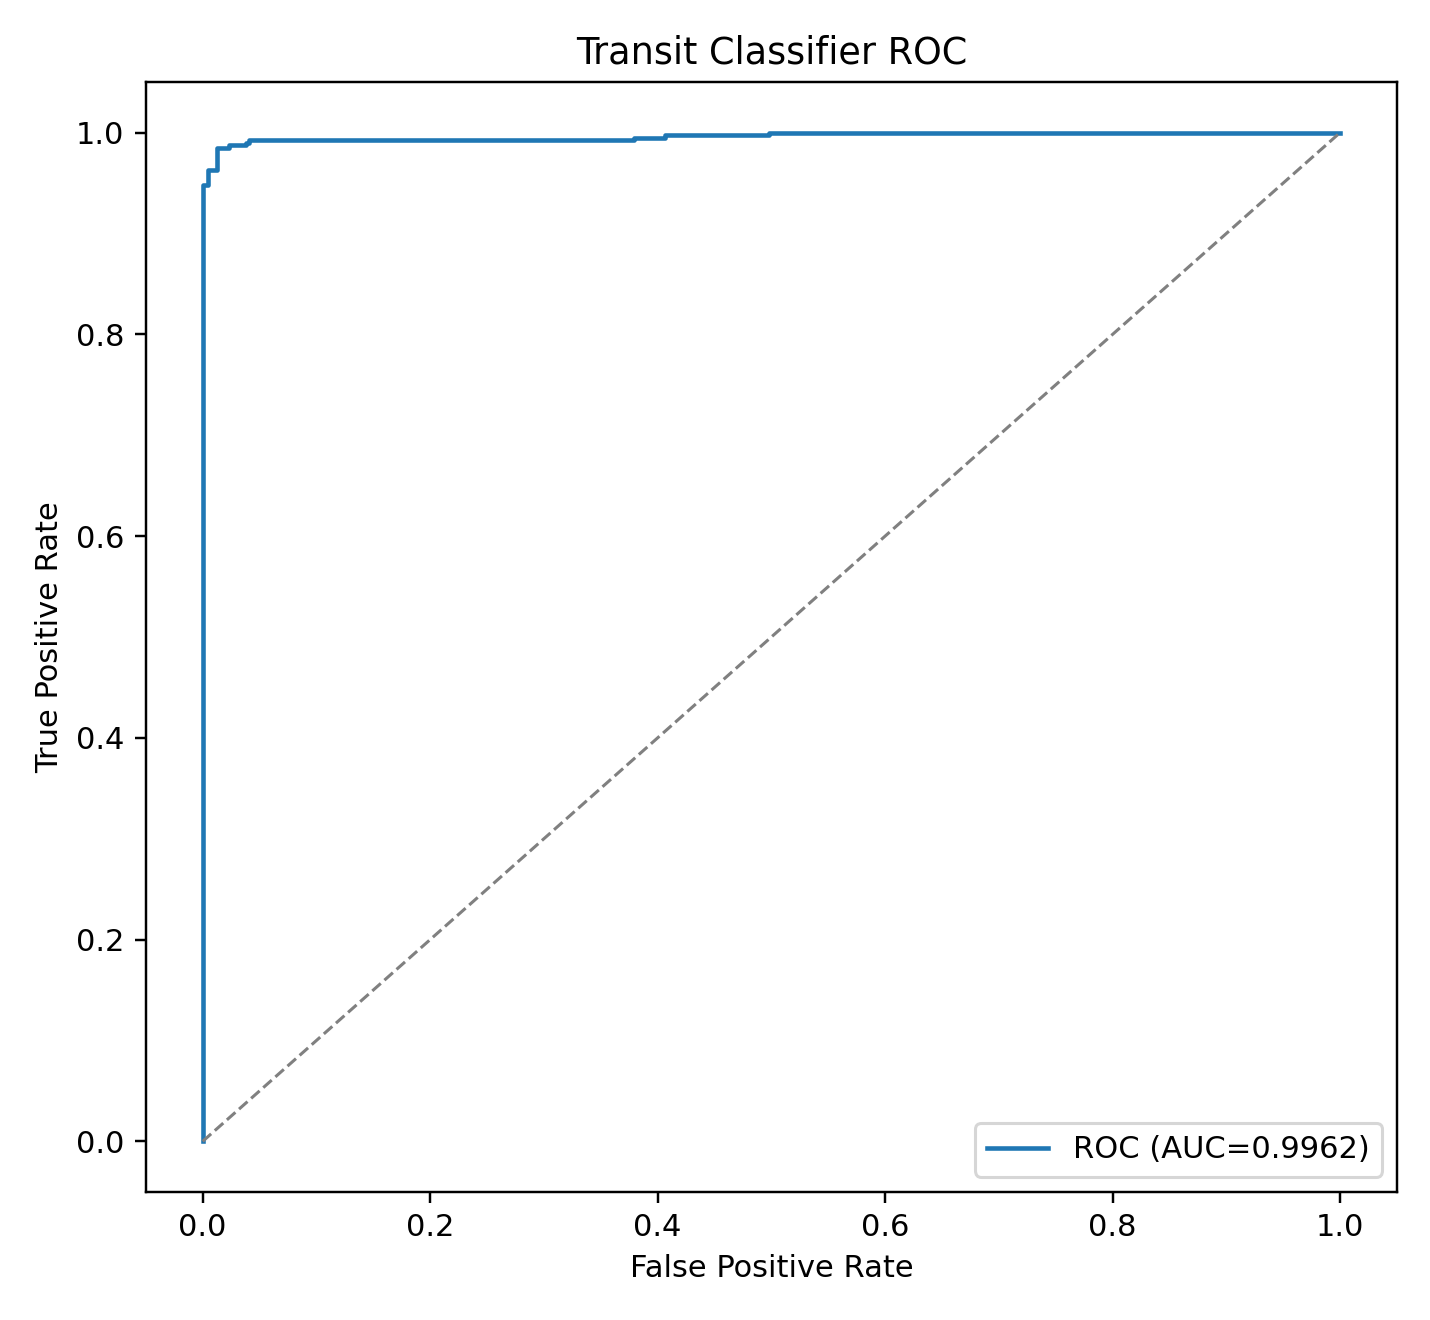

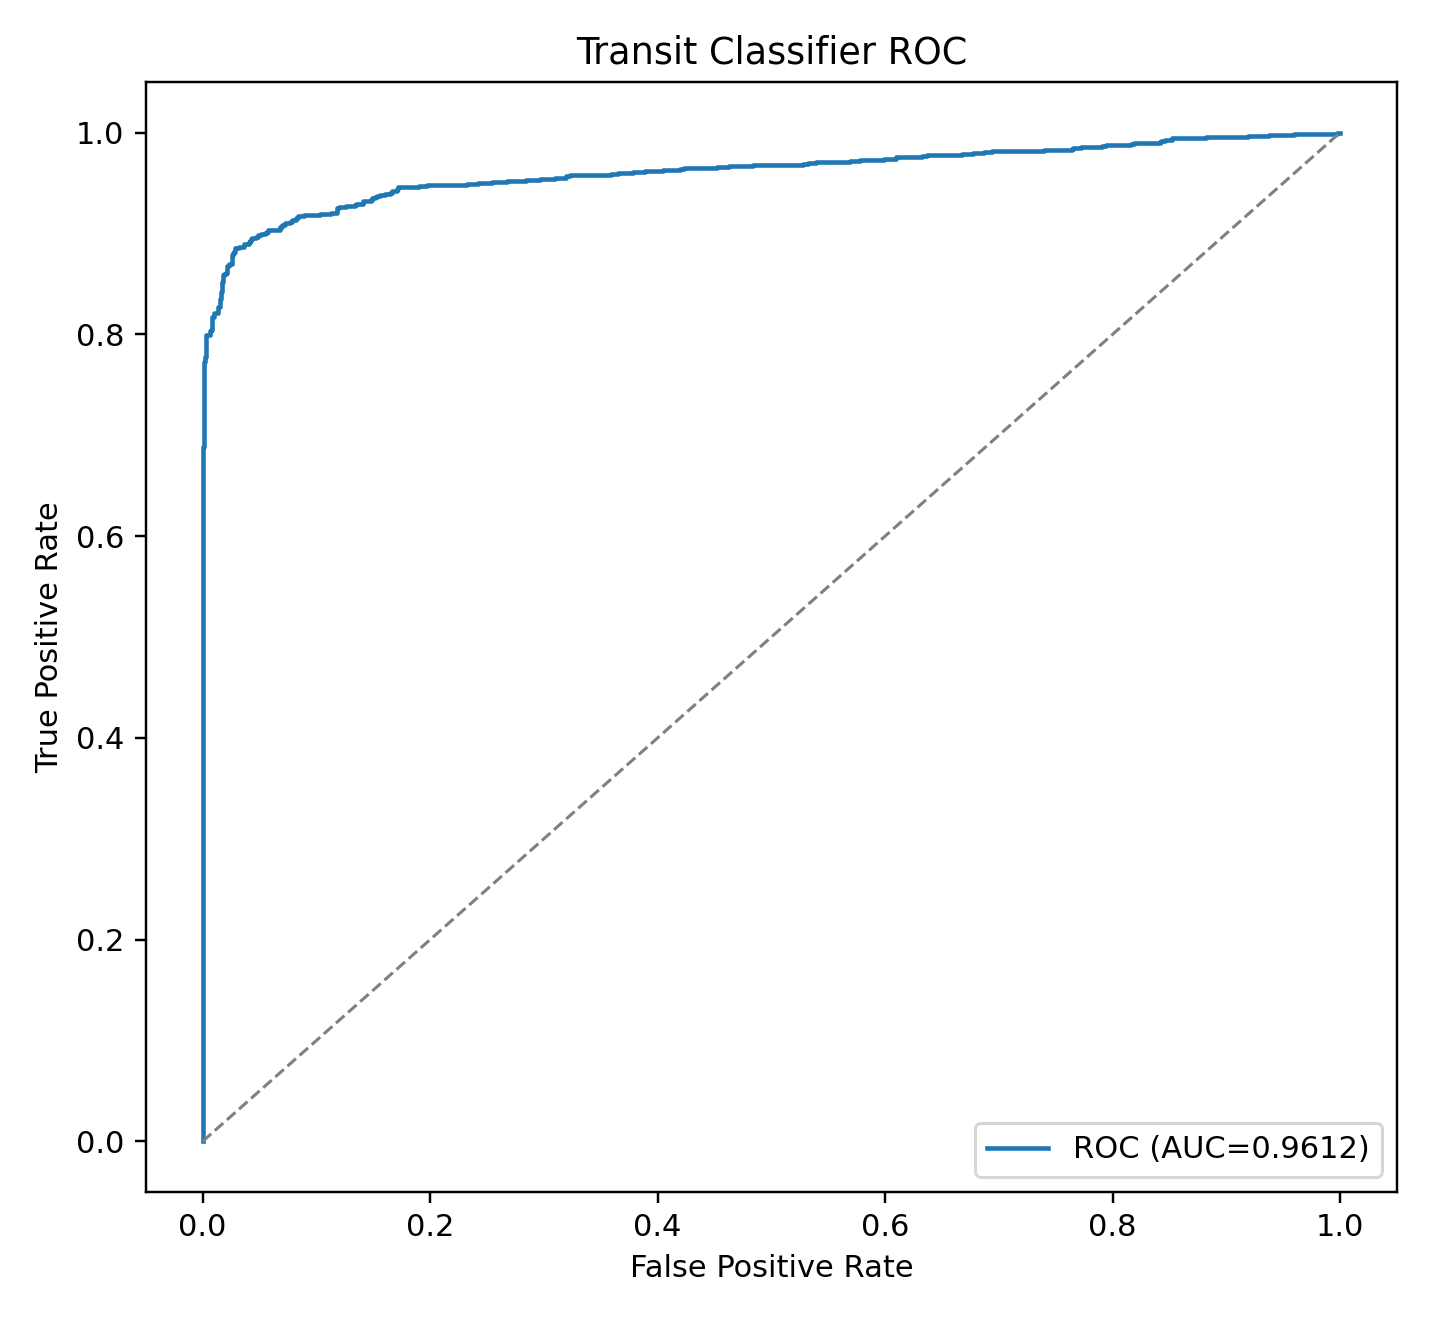

In [6]:
# Visualizations
from IPython.display import Image, display

for p in [
    'artifacts/autoencoder/recon_examples.png',
    'artifacts/autoencoder/loss_curve.png',
    'artifacts/clustering/latent_scatter.png',
    'artifacts/clustering/cluster_means.png',
    'artifacts/transit/roc_curve.png',
    'artifacts/transit/stress_roc_curve.png',
]:
    display(Image(filename=p))


## Withheld Data Test (New FITS Files)
Generate new synthetic FITS files and run inference on them.


In [7]:
# Generate new synthetic FITS
!python scripts/generate_synthetic_fits.py --out-dir data/withheld_fits --n-samples 8

# Run inference on withheld data
!python -m planar infer --config configs/verify.yaml --data-dir data/withheld_fits


Generated 8 FITS files in data/withheld_fits


/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2026-03-13 15:45:49,361 | INFO | planar.pipelines.inference | Inference complete, outputs written to artifacts/inference


## Withheld Data Test (Observational Light Curves)
Create a small labeled observational-style dataset (CSV) and evaluate the classifier on it.


In [8]:
# Run full pipeline with observational eval enabled
!python -m planar run --config configs/verify_observational.yaml


2026-03-13 15:45:55,070 | INFO | planar.pipelines.autoencoder | AE loaded pretrained checkpoint; val_loss=0.03757 val_mse=0.00806


2026-03-13 15:45:57,100 | INFO | planar.pipelines.autoencoder | Autoencoder artifacts written to artifacts/autoencoder


/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify

/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_f

2026-03-13 15:46:01,555 | INFO | planar.pipelines.clustering | Clustering complete: method=hdbscan_all_noise_fallback_kmeans reducer=pca silhouette=0.33633577823638916 noise=0.000


2026-03-13 15:46:07,483 | INFO | planar.pipelines.transit | Transit training complete. test_auc=0.9962 stress_auc=0.9612


/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/atharva/Desktop/untitled folder/PLANAR/.venv_exxa_verify/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: Runtime

2026-03-13 15:46:15,459 | INFO | planar.pipelines.inference | Inference complete, outputs written to artifacts/inference


2026-03-13 15:46:15,507 | INFO | planar.pipelines.full | Run report written to reports/PLANAR_REPORT.md


## End
This notebook completes the required EXXA pipeline and demonstrates withheld-data processing.
